In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score
)

pd.set_option("display.width", 120)
print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv("yaleemmlc_admissionprediction_triage.csv")
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Loaded 7430 patients and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
TARGET = "esi"

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

X = df[FEATURES]
y = df[TARGET]

print("Model will use", len(FEATURES), "features to predict:", TARGET)

Model will use 209 features to predict: esi


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 5944
Testing patients:  1486


In [5]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
print("Dummy baseline accuracy:", dummy.score(X_test, y_test))

Dummy baseline accuracy: 0.38896366083445494


In [6]:
# Some features may contain stray NaNs after coercion — impute with median first
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

logreg_accuracy = logreg.score(X_test_scaled, y_test)
print(f"Logistic Regression Accuracy: {logreg_accuracy:.3f}")

Logistic Regression Accuracy: 0.657


In [7]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

tree_accuracy = tree.score(X_test, y_test)
print(f"Decision Tree Accuracy: {tree_accuracy:.3f}")

Decision Tree Accuracy: 0.571


In [8]:
pred_logreg = logreg.predict(X_test_scaled)
pred_tree = tree.predict(X_test)

print("Example predictions (logreg):", pred_logreg[:10])
print("Example predictions (decision tree):", pred_tree[:10])

Example predictions (logreg): [2. 3. 3. 2. 2. 2. 3. 3. 4. 2.]
Example predictions (decision tree): [3. 3. 3. 3. 3. 2. 3. 2. 3. 3.]


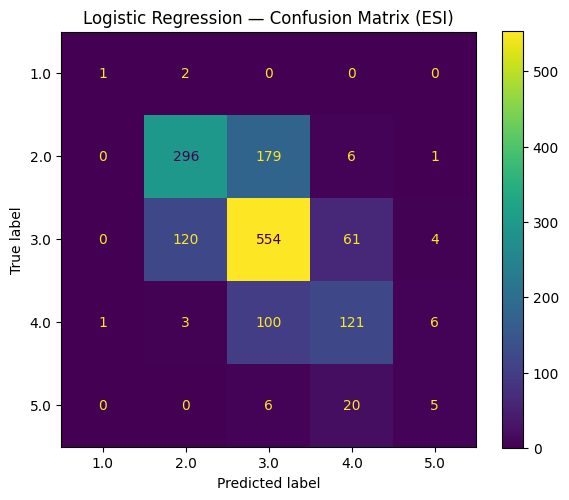

In [9]:
os.makedirs("docs", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax)
ax.set_title("Logistic Regression — Confusion Matrix (ESI)")
plt.tight_layout()
plt.savefig("docs/w6_confusion_logreg.png", dpi=120, bbox_inches="tight")
plt.show()

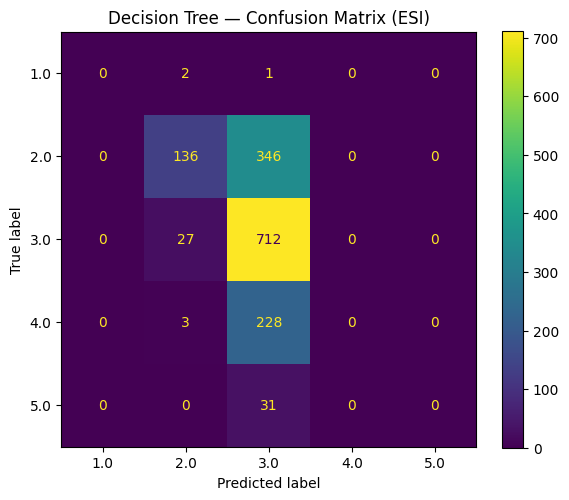

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_tree, ax=ax)
ax.set_title("Decision Tree — Confusion Matrix (ESI)")
plt.tight_layout()
plt.savefig("docs/w6_confusion_tree.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
print("===== Logistic Regression =====")
print(classification_report(y_test, pred_logreg, digits=3))

print("\n===== Decision Tree =====")
print(classification_report(y_test, pred_tree, digits=3))

===== Logistic Regression =====
              precision    recall  f1-score   support

         1.0      0.500     0.333     0.400         3
         2.0      0.703     0.614     0.656       482
         3.0      0.660     0.750     0.702       739
         4.0      0.582     0.524     0.551       231
         5.0      0.312     0.161     0.213        31

    accuracy                          0.657      1486
   macro avg      0.552     0.476     0.504      1486
weighted avg      0.654     0.657     0.653      1486


===== Decision Tree =====
              precision    recall  f1-score   support

         1.0      0.000     0.000     0.000         3
         2.0      0.810     0.282     0.418       482
         3.0      0.540     0.963     0.692       739
         4.0      0.000     0.000     0.000       231
         5.0      0.000     0.000     0.000        31

    accuracy                          0.571      1486
   macro avg      0.270     0.249     0.222      1486
weighted avg      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
for name, preds in [("Logistic Regression", pred_logreg), ("Decision Tree", pred_tree)]:
    macro_f1 = f1_score(y_test, preds, average="macro")
    weighted_f1 = f1_score(y_test, preds, average="weighted")
    esi1_recall = recall_score(y_test, preds, labels=[1], average=None)[0]

    print(f"--- {name} ---")
    print(f"Macro F1:     {macro_f1:.3f}")
    print(f"Weighted F1:  {weighted_f1:.3f}")
    print(f"ESI-1 Recall: {esi1_recall:.3f}\n")

--- Logistic Regression ---
Macro F1:     0.504
Weighted F1:  0.653
ESI-1 Recall: 0.333

--- Decision Tree ---
Macro F1:     0.222
Weighted F1:  0.480
ESI-1 Recall: 0.000



In [13]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

results = []
for name, preds in [("Dummy Baseline", dummy.predict(X_test)),
                     ("Logistic Regression", pred_logreg),
                     ("Decision Tree", pred_tree)]:
    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average="macro")
    weighted_f1 = f1_score(y_test, preds, average="weighted")
    esi1_recall = recall_score(y_test, preds, labels=[1], average=None, zero_division=0)[0]
    results.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "Macro F1": round(macro_f1, 3),
        "Weighted F1": round(weighted_f1, 3),
        "Recall (ESI 1)": round(esi1_recall, 3)
    })

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

              Model  Accuracy  Macro F1  Weighted F1  Recall (ESI 1)
     Dummy Baseline     0.389     0.200        0.387           0.000
Logistic Regression     0.657     0.504        0.653           0.333
      Decision Tree     0.571     0.222        0.480           0.000


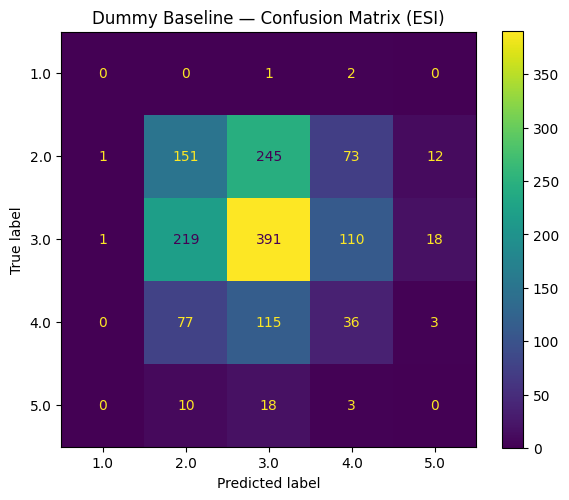

In [14]:
pred_dummy = dummy.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_dummy, ax=ax)
ax.set_title("Dummy Baseline — Confusion Matrix (ESI)")
plt.tight_layout()
plt.savefig("docs/confusion_matrix_dummy.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
for name, preds in [("Dummy Baseline", pred_dummy),
                     ("Logistic Regression", pred_logreg),
                     ("Decision Tree", pred_tree)]:
    print(f"===== {name} =====")
    print(classification_report(y_test, preds, digits=3, zero_division=0))
    print()

===== Dummy Baseline =====
              precision    recall  f1-score   support

         1.0      0.000     0.000     0.000         3
         2.0      0.330     0.313     0.322       482
         3.0      0.508     0.529     0.518       739
         4.0      0.161     0.156     0.158       231
         5.0      0.000     0.000     0.000        31

    accuracy                          0.389      1486
   macro avg      0.200     0.200     0.200      1486
weighted avg      0.385     0.389     0.387      1486


===== Logistic Regression =====
              precision    recall  f1-score   support

         1.0      0.500     0.333     0.400         3
         2.0      0.703     0.614     0.656       482
         3.0      0.660     0.750     0.702       739
         4.0      0.582     0.524     0.551       231
         5.0      0.312     0.161     0.213        31

    accuracy                          0.657      1486
   macro avg      0.552     0.476     0.504      1486
weighted avg     

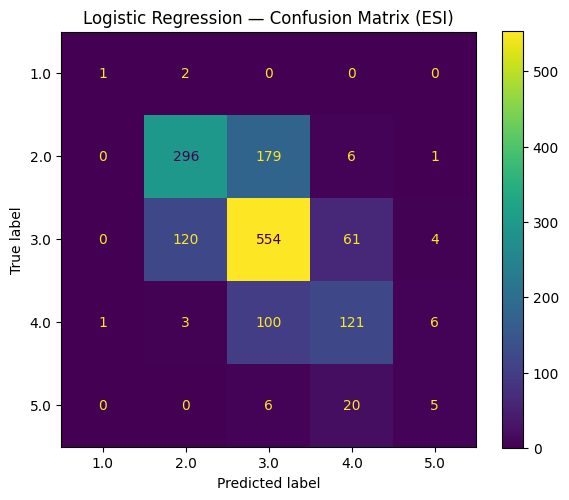

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax)
ax.set_title("Logistic Regression — Confusion Matrix (ESI)")
plt.tight_layout()
plt.savefig("docs/confusion_matrix_logistic.png", dpi=120, bbox_inches="tight")
plt.show()

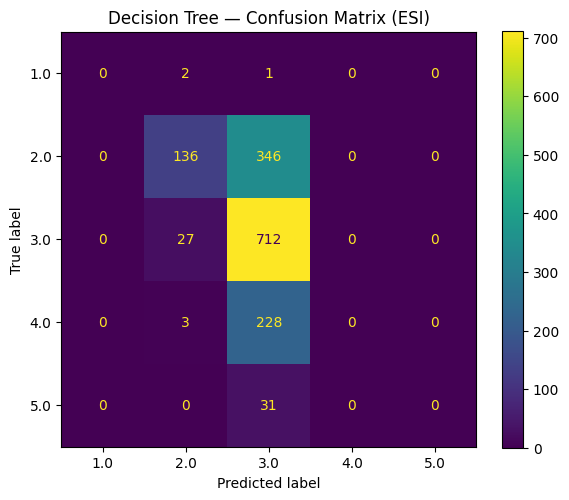

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_tree, ax=ax)
ax.set_title("Decision Tree — Confusion Matrix (ESI)")
plt.tight_layout()
plt.savefig("docs/confusion_matrix_tree.png", dpi=120, bbox_inches="tight")
plt.show()